# ⚠️ Módulo 16: Armadilhas em Machine Learning

## Objetivos deste módulo

Ao final deste notebook você será capaz de:

1. **Identificar e evitar Data Leakage** — a armadilha mais perigosa em ML
2. **Diagnosticar overfitting e underfitting** usando a decomposição bias-variância
3. **Tratar class imbalance** com `class_weight`, SMOTE e ajuste de threshold
4. **Compreender a maldição da dimensionalidade** e suas implicações práticas
5. **Aplicar correção de Bonferroni** em múltiplos testes estatísticos
6. **Usar um checklist** das 8 armadilhas mais comuns em projetos reais

---

> **Por que este módulo importa?** Modelos de ML falham em produção com muito mais frequência
> do que o esperado. A maioria das falhas não é por algoritmo inadequado, mas por **erros
> metodológicos evitáveis** — os mesmos que este módulo ensina a detectar e corrigir.


## 2. Teoria

### 2.1 Decomposição Bias-Variância
$$\mathbb{E}\left[(y - \hat{f}(x))^2\right] = \underbrace{\text{Bias}^2[\hat{f}(x)]}_{\text{underfitting}} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{overfitting}} + \underbrace{\sigma^2}_{\text{irredutível}}$$

### 2.2 Data Leakage
Ocorre quando informação do futuro ou do alvo "vaza" para as features de treinamento.
**Consequência:** Acurácia 99% no treino → 65% em produção.

### 2.3 Class Imbalance
Para datasets desbalanceados, acurácia é enganosa:
$$\text{Acurácia} = \frac{VP + VN}{Total} \approx 99\% \text{ só prevendo "não fraude"!}$$
**SMOTE** cria exemplos sintéticos para a classe minoritária.

### 2.4 Maldição da Dimensionalidade
Em alta dimensão, todos os pontos ficam igualmente distantes:
$$\lim_{p\to\infty} \frac{d_{max} - d_{min}}{d_{min}} \to 0$$
O volume de um hipercubo cresce exponencialmente: $V_p = L^p$

### 2.5 Correção de Bonferroni (Multiple Testing)
$$\alpha_{\text{corrigido}} = \frac{\alpha}{m}$$
Testar $m$ hipóteses sem correção infla a taxa de falsos positivos.


💀 ARMADILHA 1: DATA LEAKAGE — A MAIS PERIGOSA!

COM leakage: AUC Treino=1.0000 | AUC Teste=1.0000

SEM leakage: AUC Treino=0.6088 | AUC Teste=0.4256


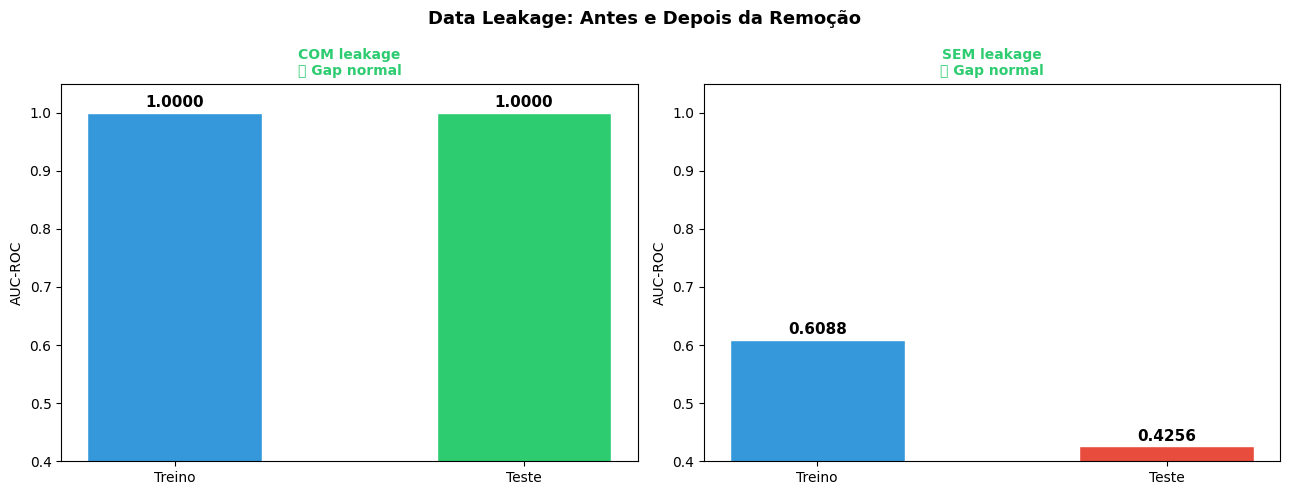


💡 Regra de Ouro: SEMPRE fit() no treino, transform() no teste!
   Nunca use StandardScaler().fit_transform(X) em todo o dataset antes de dividir!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
import os
os.makedirs('../imagens', exist_ok=True)

print("=" * 60)
print("💀 ARMADILHA 1: DATA LEAKAGE — A MAIS PERIGOSA!")
print("=" * 60)

# Dataset de fraude bancária
n = 2000
X_real = np.random.randn(n, 5)
y_fraude = np.random.binomial(1, 0.03, n)  # 3% de fraude

# Com leakage: incluir uma feature que "vaza" o target
# (ex: "alerta_fraude_gerado" que é criado DEPOIS da transação ser marcada)
X_com_leak = np.column_stack([X_real, y_fraude + np.random.randn(n)*0.1])  # feature vaza o target!
X_sem_leak = X_real.copy()

feat_com_leak = ['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Alerta_Fraude_LEAK']
feat_sem_leak = ['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5']

resultados_leak = {}
for descricao, X_usado, feats in [
    ('COM leakage', X_com_leak, feat_com_leak),
    ('SEM leakage', X_sem_leak, feat_sem_leak)
]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_usado, y_fraude, test_size=0.25,
                                                 stratify=y_fraude, random_state=42)
    modelo = Pipeline([('sc', StandardScaler()),
                        ('lr', LogisticRegression(class_weight='balanced', random_state=42))])
    modelo.fit(X_tr, y_tr)
    auc_treino = roc_auc_score(y_tr, modelo.predict_proba(X_tr)[:,1])
    auc_teste = roc_auc_score(y_te, modelo.predict_proba(X_te)[:,1])
    resultados_leak[descricao] = {'AUC Treino': auc_treino, 'AUC Teste': auc_teste}
    print(f"\n{descricao}: AUC Treino={auc_treino:.4f} | AUC Teste={auc_teste:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Data Leakage: Antes e Depois da Remoção', fontsize=13, fontweight='bold')

for ax, (desc, metricas) in zip(axes, resultados_leak.items()):
    valores = [metricas['AUC Treino'], metricas['AUC Teste']]
    cores = ['#3498db', '#e74c3c' if metricas['AUC Teste'] < 0.9 else '#2ecc71']
    bars = ax.bar(['Treino', 'Teste'], valores, color=cores, edgecolor='white', width=0.5)
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel('AUC-ROC')
    ax.set_title(f'{desc}\n{"🚨 GAP ENORME = Leakage!" if abs(metricas["AUC Treino"]-metricas["AUC Teste"]) > 0.2 else "✅ Gap normal"}',
                  fontweight='bold', fontsize=10,
                  color='#e74c3c' if abs(metricas['AUC Treino']-metricas['AUC Teste']) > 0.2 else '#2ecc71')
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../imagens/16_data_leakage.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Regra de Ouro: SEMPRE fit() no treino, transform() no teste!")
print("   Nunca use StandardScaler().fit_transform(X) em todo o dataset antes de dividir!")

📊 ARMADILHA 2: OVERFITTING E TRADE-OFF BIAS-VARIÂNCIA


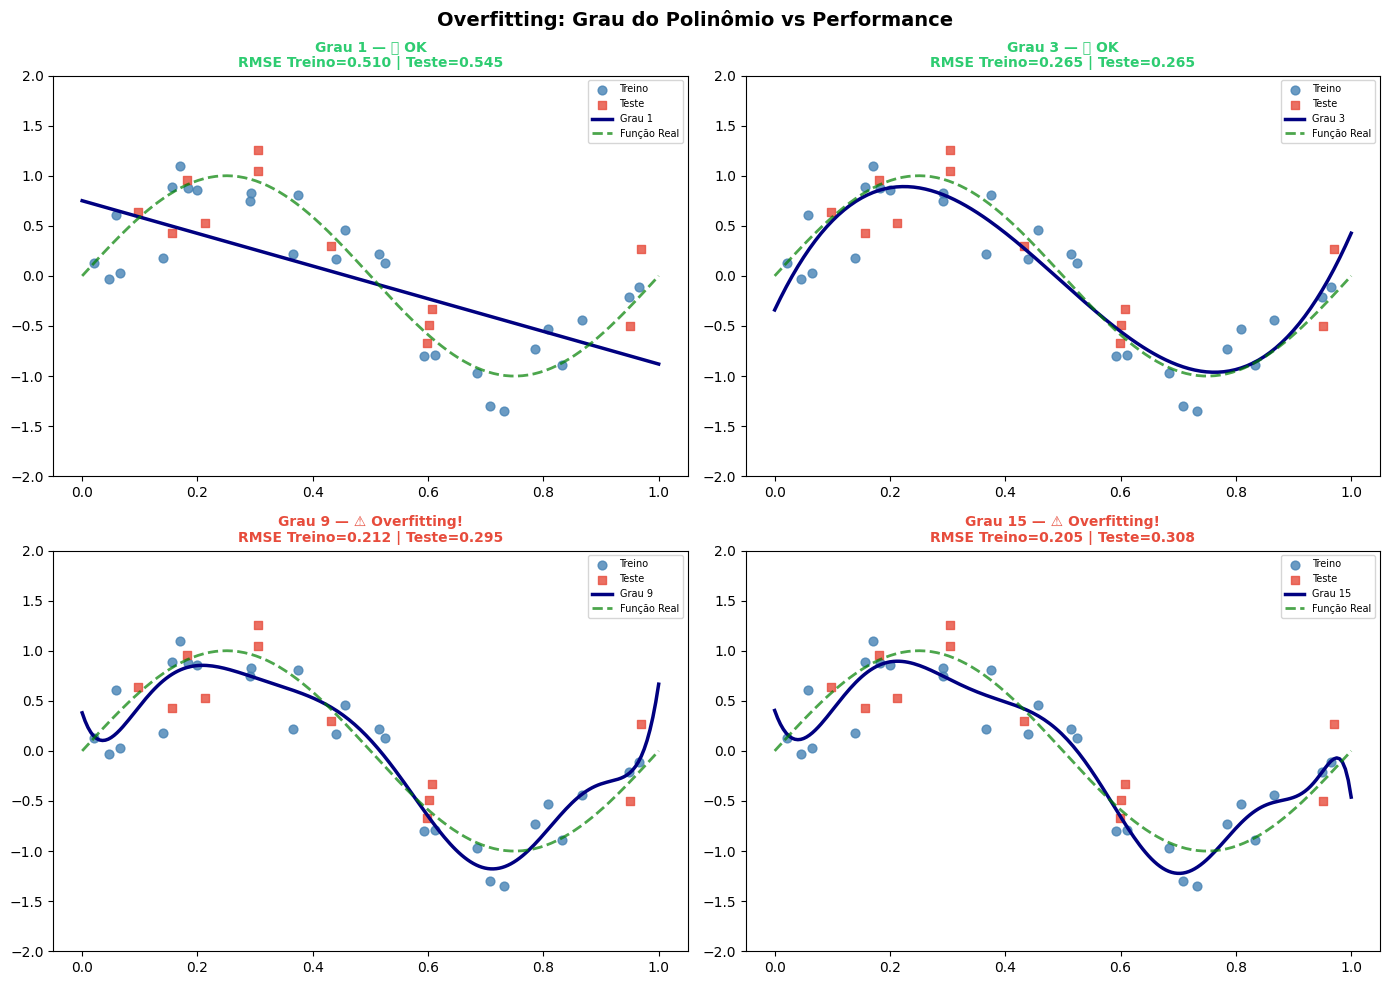

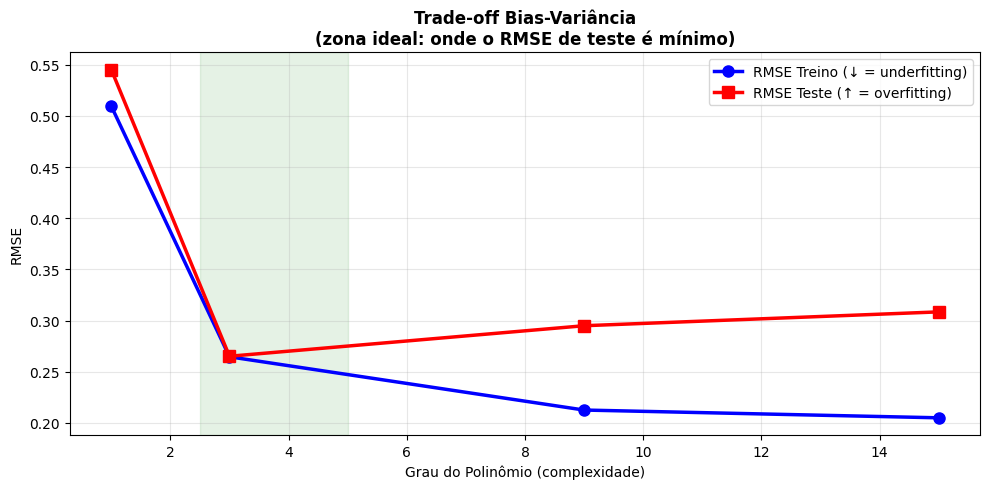

In [2]:
print("=" * 60)
print("📊 ARMADILHA 2: OVERFITTING E TRADE-OFF BIAS-VARIÂNCIA")
print("=" * 60)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Regressão com diferentes graus de polinômio
np.random.seed(42)
n_pts = 40
X_poly = np.sort(np.random.uniform(0, 1, n_pts))
y_poly = np.sin(2 * np.pi * X_poly) + np.random.randn(n_pts) * 0.3

X_poly_tr, X_poly_te, y_poly_tr, y_poly_te = train_test_split(
    X_poly.reshape(-1,1), y_poly, test_size=0.3, random_state=42
)

graus = [1, 3, 9, 15]
X_range = np.linspace(0, 1, 200).reshape(-1, 1)
X_verdadeiro = np.linspace(0, 1, 200)
y_verdadeiro = np.sin(2 * np.pi * X_verdadeiro)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Overfitting: Grau do Polinômio vs Performance', fontsize=14, fontweight='bold')
axes = axes.flatten()

erros_treino = []
erros_teste = []
for i, (ax, grau) in enumerate(zip(axes, graus)):
    poly = PolynomialFeatures(grau)
    X_tr_poly = poly.fit_transform(X_poly_tr)
    X_te_poly = poly.transform(X_poly_te)
    X_range_poly = poly.transform(X_range)

    modelo_poly = Ridge(alpha=1e-10)
    modelo_poly.fit(X_tr_poly, y_poly_tr)

    y_pred_tr = modelo_poly.predict(X_tr_poly)
    y_pred_te = modelo_poly.predict(X_te_poly)
    rmse_tr = np.sqrt(mean_squared_error(y_poly_tr, y_pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_poly_te, y_pred_te))
    erros_treino.append(rmse_tr)
    erros_teste.append(rmse_te)

    ax.scatter(X_poly_tr, y_poly_tr, color='steelblue', s=40, alpha=0.8, label='Treino')
    ax.scatter(X_poly_te, y_poly_te, color='#e74c3c', s=40, alpha=0.8, marker='s', label='Teste')
    ax.plot(X_range, modelo_poly.predict(X_range_poly), 'navy', lw=2.5, label=f'Grau {grau}')
    ax.plot(X_range, y_verdadeiro, 'g--', lw=2, alpha=0.7, label='Função Real')

    status = '✅ OK' if grau <= 3 else ('⚠️ Overfitting!' if grau >= 9 else '→ Atenção')
    ax.set_title(f'Grau {grau} — {status}\nRMSE Treino={rmse_tr:.3f} | Teste={rmse_te:.3f}',
                  fontweight='bold', fontsize=10,
                  color='#2ecc71' if grau <= 3 else '#e74c3c')
    ax.legend(fontsize=7); ax.set_ylim(-2, 2)

plt.tight_layout()
plt.savefig('../imagens/16_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

# Curva bias-variância
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(graus, erros_treino, 'b-o', lw=2.5, ms=8, label='RMSE Treino (↓ = underfitting)')
ax.plot(graus, erros_teste, 'r-s', lw=2.5, ms=8, label='RMSE Teste (↑ = overfitting)')
ax.set_xlabel('Grau do Polinômio (complexidade)'); ax.set_ylabel('RMSE')
ax.set_title('Trade-off Bias-Variância\n(zona ideal: onde o RMSE de teste é mínimo)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.axvspan(2.5, 5, alpha=0.1, color='green', label='Zona ideal')
plt.tight_layout()
plt.savefig('../imagens/16_bias_variancia.png', dpi=150, bbox_inches='tight')
plt.show()

⚖️ ARMADILHA 3: CLASS IMBALANCE

Dataset: 79 fraudes em 5000 transações (1.6%)

Sem balanceamento: Acurácia=0.984, AUC=0.546
  → Prevê tudo como classe 0: Acurácia = 0.984 😱

Com class_weight='balanced': AUC=0.561
Com SMOTE:                 AUC=0.550


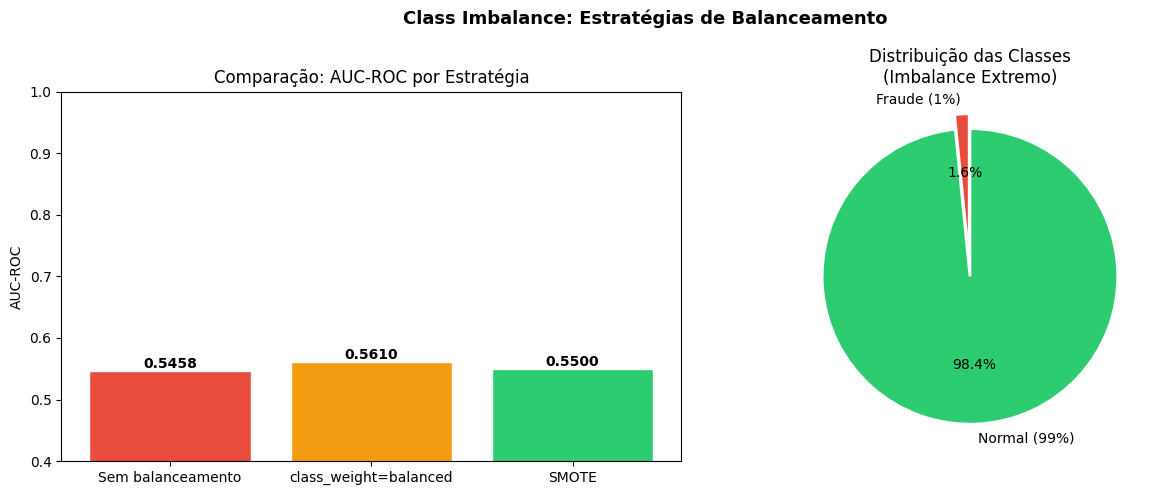

In [3]:
print("=" * 60)
print("⚖️ ARMADILHA 3: CLASS IMBALANCE")
print("=" * 60)

# Dataset muito desbalanceado (1% fraude)
X_imb, y_imb = make_classification(n_samples=5000, n_features=6, n_informative=4,
                                     weights=[0.99, 0.01], random_state=42)
X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(X_imb, y_imb, test_size=0.25,
                                                              stratify=y_imb, random_state=42)
print(f"\nDataset: {y_imb.sum()} fraudes em {len(y_imb)} transações ({y_imb.mean():.1%})")

# Sem balanceamento
lr_imb = LogisticRegression(random_state=42, max_iter=500)
lr_imb.fit(X_tr_imb, y_tr_imb)
auc_sem = roc_auc_score(y_te_imb, lr_imb.predict_proba(X_te_imb)[:,1])
acc_sem = lr_imb.score(X_te_imb, y_te_imb)
print(f"\nSem balanceamento: Acurácia={acc_sem:.3f}, AUC={auc_sem:.3f}")
print(f"  → Prevê tudo como classe 0: Acurácia = {(y_te_imb==0).mean():.3f} 😱")

# Com class_weight='balanced'
lr_bal = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
lr_bal.fit(X_tr_imb, y_tr_imb)
auc_bal = roc_auc_score(y_te_imb, lr_bal.predict_proba(X_te_imb)[:,1])
print(f"\nCom class_weight='balanced': AUC={auc_bal:.3f}")

# Com SMOTE
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    X_sm, y_sm = sm.fit_resample(X_tr_imb, y_tr_imb)
    lr_smote = LogisticRegression(random_state=42, max_iter=500)
    lr_smote.fit(X_sm, y_sm)
    auc_smote = roc_auc_score(y_te_imb, lr_smote.predict_proba(X_te_imb)[:,1])
    print(f"Com SMOTE:                 AUC={auc_smote:.3f}")
    SMOTE_OK = True
except ImportError:
    SMOTE_OK = False
    auc_smote = auc_bal
    print("imbalanced-learn não disponível (pip install imbalanced-learn)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Class Imbalance: Estratégias de Balanceamento', fontsize=13, fontweight='bold')

nomes_met = ['Sem balanceamento', 'class_weight=balanced', 'SMOTE' if SMOTE_OK else 'Sem SMOTE']
aucs = [auc_sem, auc_bal, auc_smote]
cores_met = ['#e74c3c', '#f39c12', '#2ecc71']
bars_met = axes[0].bar(nomes_met, aucs, color=cores_met, edgecolor='white')
axes[0].set_ylim(0.4, 1.0); axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Comparação: AUC-ROC por Estratégia')
for bar, v in zip(bars_met, aucs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.4f}',
                  ha='center', fontweight='bold')

# Distribuição das classes
axes[1].pie([y_imb.sum(), (y_imb==0).sum()], labels=['Fraude (1%)', 'Normal (99%)'],
             colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90,
             wedgeprops=dict(edgecolor='white', linewidth=2), explode=(0.1, 0))
axes[1].set_title('Distribuição das Classes\n(Imbalance Extremo)')

plt.tight_layout()
plt.savefig('../imagens/16_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

🎯 ARMADILHA 4: MALDIÇÃO DA DIMENSIONALIDADE


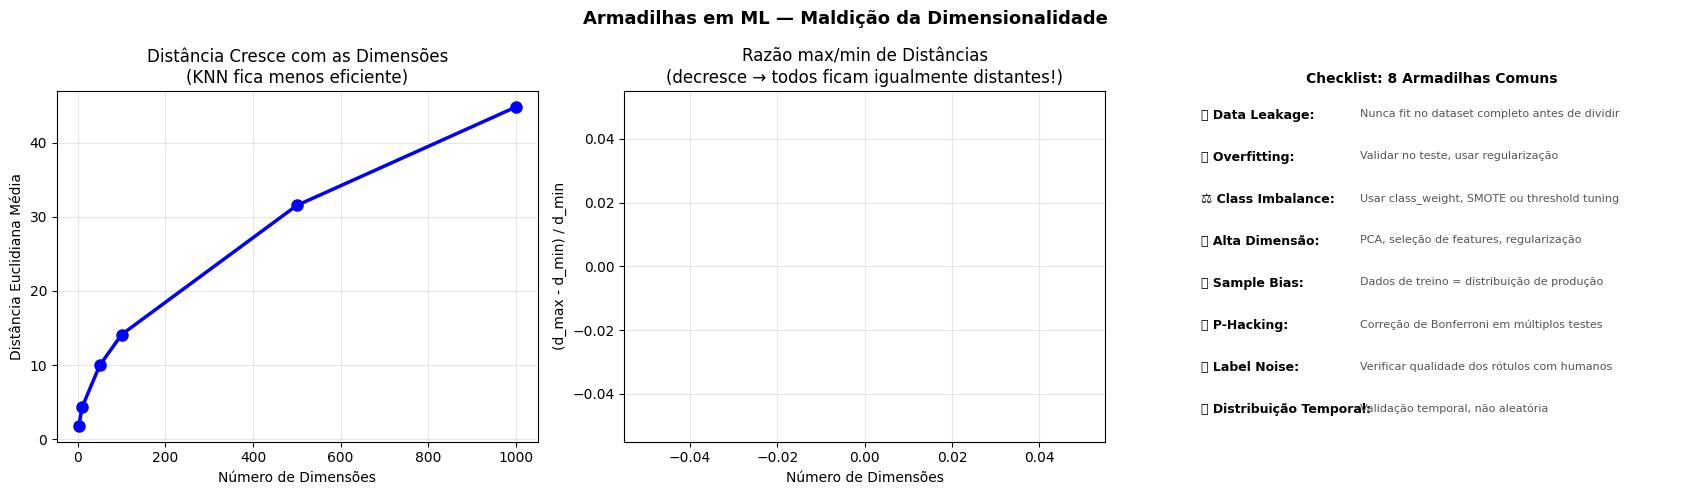

In [4]:
print("=" * 60)
print("🎯 ARMADILHA 4: MALDIÇÃO DA DIMENSIONALIDADE")
print("=" * 60)

dims = [2, 10, 50, 100, 500, 1000]
n_pts_dim = 500

distancias_medias = []
razoes_dist = []
for d in dims:
    X_d = np.random.randn(n_pts_dim, d)
    from sklearn.metrics.pairwise import euclidean_distances
    dists = euclidean_distances(X_d[:100], X_d[:100])
    np.fill_diagonal(dists, np.inf)
    d_min = dists.min()
    d_max = dists.max()
    d_med = np.mean(dists[dists < np.inf])
    razoes_dist.append((d_max - d_min) / max(d_min, 1e-10))
    distancias_medias.append(d_med)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Armadilhas em ML — Maldição da Dimensionalidade', fontsize=13, fontweight='bold')

axes[0].plot(dims, distancias_medias, 'b-o', lw=2.5, ms=8)
axes[0].set_xlabel('Número de Dimensões'); axes[0].set_ylabel('Distância Euclidiana Média')
axes[0].set_title('Distância Cresce com as Dimensões\n(KNN fica menos eficiente)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(dims, razoes_dist, 'r-s', lw=2.5, ms=8)
axes[1].set_xlabel('Número de Dimensões')
axes[1].set_ylabel('(d_max - d_min) / d_min')
axes[1].set_title('Razão max/min de Distâncias\n(decresce → todos ficam igualmente distantes!)')
axes[1].grid(True, alpha=0.3)

# Checklist visual de armadilhas
armadilhas = [
    ('Data Leakage', '💀', 'Nunca fit no dataset completo antes de dividir'),
    ('Overfitting', '🎯', 'Validar no teste, usar regularização'),
    ('Class Imbalance', '⚖️', 'Usar class_weight, SMOTE ou threshold tuning'),
    ('Alta Dimensão', '🌌', 'PCA, seleção de features, regularização'),
    ('Sample Bias', '👥', 'Dados de treino = distribuição de produção'),
    ('P-Hacking', '📊', 'Correção de Bonferroni em múltiplos testes'),
    ('Label Noise', '🏷️', 'Verificar qualidade dos rótulos com humanos'),
    ('Distribuição Temporal', '📅', 'Validação temporal, não aleatória'),
]

axes[2].axis('off')
y_pos = 0.95
for emoji, titulo, descricao in [(e, t, d) for t, e, d in armadilhas]:
    axes[2].text(0.02, y_pos, f"{emoji} {titulo}:", transform=axes[2].transAxes,
                  fontsize=9, fontweight='bold', va='top')
    axes[2].text(0.35, y_pos, descricao, transform=axes[2].transAxes,
                  fontsize=8, va='top', color='#555')
    y_pos -= 0.12
axes[2].set_title('Checklist: 8 Armadilhas Comuns', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../imagens/16_dimensionalidade_checklist.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. As 10 Regras de Ouro do Machine Learning

| # | Regra | Por que importa |
|---|-------|-----------------|
| 1 | **Nunca faça `fit` no dataset completo antes de dividir** | Evita data leakage |
| 2 | **Sempre use Pipeline** | Encapsula pré-processamento e evita vazamento |
| 3 | **AUC > Acurácia em dados desbalanceados** | Acurácia é enganosa com classes raras |
| 4 | **Valide temporalmente quando os dados têm data** | Evita lookahead bias |
| 5 | **Olhe para os erros, não só para as métricas** | Entenda onde o modelo falha |
| 6 | **Baseline simples primeiro** | Mede o ganho real do modelo complexo |
| 7 | **Documente tudo** | Model Card, decisões de design, limitações |
| 8 | **Verifique fairness antes do deploy** | Modelos podem discriminar sem que percebamos |
| 9 | **Monitore em produção** | PSI, métricas, distribuição das features |
| 10 | **Retreine com dados novos** | Distribuições mudam — modelos envelhecem |

---

## 8. Exercícios Finais

1. **Data Leakage temporal**: Crie um dataset de séries temporais e demonstre o leakage que
   ocorre quando se usa `train_test_split` aleatório (em vez de separação por data).

2. **Threshold tuning**: No dataset de fraude (1% de fraude), o threshold padrão de 0.5 é adequado?
   Encontre o threshold que maximiza o F1-score para a classe positiva.

3. **Bias-variância experimental**: Para Random Forests, varie `max_depth` de 1 a 20 e plote
   as curvas de treino e validação. Identifique o ponto de overfitting.

4. **Dimensionalidade e KNN**: Treine um KNN com k=5 em datasets com 2, 10, 50 e 100 features
   (todas irrelevantes exceto 2). Como a acurácia muda? O que isso implica?

5. **Bonferroni na prática**: Gere 100 features aleatórias e calcule o p-value de correlação
   de cada uma com o target. Quantas parecem significativas (p<0.05) sem correção?
   E com correção de Bonferroni?

---

## 🎓 Parabéns! Você Completou o Curso de Machine Learning!

### 📚 O que você aprendeu:
| Módulo | Tópico | Status |
|--------|--------|--------|
| 1 | Introdução ao ML | ✅ |
| 2 | Pré-processamento | ✅ |
| 3 | Feature Engineering | ✅ |
| 4 | Regressão | ✅ |
| 5 | Classificação | ✅ |
| 6 | Avaliação de Modelos | ✅ |
| 7 | Regras de Associação | ✅ |
| 8 | Clustering | ✅ |
| 9 | Redes Neurais | ✅ |
| 10 | SVMs | ✅ |
| 11 | Ensemble Methods | ✅ |
| 12 | Redes Bayesianas | ✅ |
| 13 | Seleção de Variáveis | ✅ |
| 14 | Interpretação (XAI) | ✅ |
| 15 | Deploy e Governança | ✅ |
| 16 | Armadilhas em ML | ✅ |

### 🚀 Próximos Passos Sugeridos:
1. **Deep Learning**: TensorFlow/Keras para CNNs e RNNs
2. **NLP**: Transformers e BERT para texto
3. **MLOps**: MLflow, DVC, monitoramento em produção
4. **Kaggle**: Competições para prática real
5. **Papers**: Ler artigos no arXiv sobre ML moderno
